In [12]:
import pandas as pd

github_raw = "https://raw.githubusercontent.com/Buket12345/climbing-ifsc-dsa210/main"
df = pd.read_csv(f"{github_raw}/final_dataset.csv")


In [13]:
country_season = (
    df.groupby(['country','season','gender'], as_index=False)
    .agg(
        mean_rank=('rank','mean'),
        events=('rank','size'),
        gdp_per_capita=('gdp_per_capita','mean')
    )
)

country_season['gender_01'] = country_season['gender'].map({'male':0,'female':1})


Linear Regression
---

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = country_season[['gdp_per_capita', 'events', 'season', 'gender_01']]
mean_rank = country_season['mean_rank']



features_train, features_test, mean_rank_train, mean_rank_test = train_test_split(features, mean_rank, test_size=0.2, random_state=42)



linear_regression = LinearRegression()
linear_regression.fit(features_train, mean_rank_train)


mean_rank_prediction = linear_regression.predict(features_test)

print("Train R squared:", linear_regression.score(features_train, mean_rank_train))
print("Test R squared:", linear_regression.score(features_test, mean_rank_test))

print("Mean Squarred Error:", mean_squared_error(mean_rank_test, mean_rank_prediction))


Train R squared: 0.20181822901698387
Test R squared: 0.20146561096883353
Mean Squarred Error: 240.5903383679286


In [16]:
coefficients = pd.DataFrame({
    'Features': features.columns,
    'Coefficients': linear_regression.coef_
})

coefficients

,Features,Coefficients
0,gdp_per_capita,-0.000043
1,events,-0.107658
2,season,0.359742
3,gender_01,-9.803230


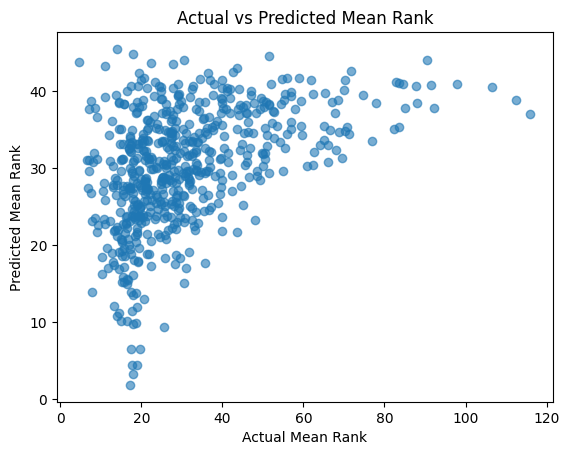

In [17]:
import matplotlib.pyplot as plt

plt.scatter(mean_rank_test, mean_rank_prediction, alpha=0.6)
plt.xlabel("Actual Mean Rank")
plt.ylabel("Predicted Mean Rank")
plt.title("Actual vs Predicted Mean Rank")
plt.show()

So here we applied linear regression to model the association between GDP per capita and average IFSC rank; for events, season, and gender. The model explained 24% of variance and showed that GDP per capita had a negative coefficient which shows that higher national economic wealth is associated with better competitive performance which is also consistent with earlier findings from EDA.

Logictic Regression
--

In [18]:
country_season['top_20'] = (country_season['mean_rank'] <= 20).astype(int)
y_top_20 = country_season['top_20']


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


features_train, features_test, mean_rank_train, mean_rank_test = train_test_split(
    features, y_top_20, test_size=0.2, random_state=42, stratify=y_top_20
)

logistic_regression = LogisticRegression(max_iter=2000)
logistic_regression.fit(features_train, mean_rank_train)

top20_predictions = logistic_regression.predict(features_test)

print("Accuracy:", accuracy_score(mean_rank_test, top20_predictions))
print("\nClassification Report:\n", classification_report(mean_rank_test, top20_predictions))
print("Confusion Matrix:\n", confusion_matrix(mean_rank_test, top20_predictions))


Accuracy: 0.7545304777594728

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.95      0.84       420
           1       0.75      0.30      0.43       187

    accuracy                           0.75       607
   macro avg       0.75      0.63      0.64       607
weighted avg       0.75      0.75      0.72       607

Confusion Matrix:
 [[401  19]
 [130  57]]


Although the model reaches an accuracy of around 77%, the classification results show that it performs much better for non top-performing country-seasons than for top performing ones. This suggests that GDP captures overall performance trends but are not sufficient to predict elite success.

The logistic regression model achieved 74% accuracy in predicting whether a country-season achieved a top 20 average rank.

For non top 20 country seasons, the model performs well, with a high recall of 0.95, meaning it can correctly identify most average or lower performing cases. This is also shown in the confusion matrix where 400 out of 419 non top-20 cases are correctly classified.

In contrast, the model struggles to identify top 20 country-seasons. The recall for this class is only 0.26 which means that the majority of high performing country-seasons are misclassified as non top-20. Out of 188 actual top 20 cases, only 49 are correctly predicted, while 139 are missed.

These results show that the model is effective at recognizing general or lower performance levels but it has limited ability to reliably predict elite outcomes. This suggests that GDP helps explain broad performance patterns but is not sufficient on their own to predict the elite outcomes.

The same train test split was used for both regression and classification models to ensure consistency across analyses.